# 00 - Data Cleaning & Feature Engineering

## Preparación y transformación del dataset de RRHH para Machine Learning

Este notebook prepara el dataset de recursos humanos antes de entrenar modelos de Machine Learning.

La etapa se centra en mejorar la calidad de los datos, controlar valores extremos, recalcular variables operacionales y crear nuevas variables con sentido de RRHH.  
No se analizan predicciones ni resultados de modelos en este notebook; eso se realiza en etapas posteriores.


# Objetivo del notebook

En este notebook voy a:

- cargar el dataset consolidado generado por el módulo `data_preprocessing`;
- revisar calidad de datos (nulos, tipos, consistencia);
- detectar valores imposibles y valores extremos;
- aplicar una limpieza conservadora;
- controlar outliers mediante clipping;
- verificar variables con comportamiento anómalo (p.ej. `ausencias_justificadas`);
- crear nuevas variables de riesgo operacional de RRHH;
- aplicar transformaciones logarítmicas para variables con distribución sesgada;
- guardar el dataset final como `dataset_rrhh_limpio.csv`.

La idea es dejar una base limpia y transformada para los notebooks posteriores.


# Enfoque utilizado

En RRHH, un valor extremo no siempre es un error.

Un empleado con muchas ausencias, un puntaje de desempeño muy alto o muchas horas de capacitación pueden representar casos reales y relevantes.  
Por eso, el enfoque de esta limpieza no será eliminar masivamente registros, sino diferenciar entre:

- **errores de datos:** valores imposibles que deben eliminarse (notas fuera de escala, días negativos, puntajes imposibles);
- **valores extremos:** datos raros que pueden contener información operacional real.

Este enfoque permite conservar información útil y preparar mejor el dataset para Machine Learning.


# 1. Configuración inicial

Importo las librerías necesarias y configuro las rutas del proyecto.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

# Agregar ruta de src al path.
sys.path.insert(0, r'C:\Users\Arturo\prueba2\src')

# Importar módulos personalizados.
from prueba2.pipelines.data_preprocessing import (
    cargar_datos_crudos, 
    normalizar_categorias,
    agregar_ausencias,
    agregar_capacitaciones,
    construir_dataset_evaluaciones,
    crear_features_empleado
)

# Configuración visual.
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
np.random.seed(42)

pd.set_option("display.max_columns", None)

# Ruta raíz del proyecto.
project_root = r'C:\Users\Arturo\prueba2'

print("Configuración inicial completada.")

Configuración inicial completada.


# 2. Carga del dataset base

Cargo el dataset consolidado generado por el módulo `data_preprocessing`.

Este dataset contiene información de empleados, ausencias, capacitaciones y evaluaciones de desempeño.


In [2]:
# Cargar datos crudos desde la carpeta raw.
print("Cargando datos crudos...")
datos_crudos = cargar_datos_crudos(os.path.join(project_root, 'data/01_raw/'))

print("\nDatasets cargados:")
for nombre, df_temp in datos_crudos.items():
    print(f"  - {nombre}: {df_temp.shape}")

# Normalizar categorias
print("\nNormalizando categorías...")
datos_crudos = normalizar_categorias(datos_crudos)

# Agregar datos de ausencias y capacitaciones
print("\nAgregando ausencias...")
aus_agg = agregar_ausencias(datos_crudos['ausencias'])

print("Agregando capacitaciones...")
cap_agg = agregar_capacitaciones(datos_crudos['capacitaciones'])

# Crear dataset consolidado con features.
print("\nCreando dataset consolidado...")
df = construir_dataset_evaluaciones(
    datos_crudos['evaluaciones'], 
    datos_crudos['empleados'], 
    aus_agg, 
    cap_agg
)

print("\nCreando features de empleado...")
df = crear_features_empleado(df)

print(f"\nDimensiones iniciales: {df.shape}")
print(f"Columnas: {list(df.columns)}")

Cargando datos crudos...
  empleados: (509, 9)
  ausencias: (640, 7)
  capacitaciones: (676, 8)
  evaluaciones: (1486, 7)

Datasets cargados:
  - empleados: (509, 9)
  - ausencias: (640, 7)
  - capacitaciones: (676, 8)
  - evaluaciones: (1486, 7)

Normalizando categorías...

Agregando ausencias...
Agregando capacitaciones...

Creando dataset consolidado...

Creando features de empleado...

Dimensiones iniciales: (1449, 37)
Columnas: ['id_evaluacion', 'id_empleado', 'periodo', 'puntaje_desempeno', 'competencias_tecnicas', 'competencias_blandas', 'evaluador', 'periodo_num', 'departamento', 'cargo', 'tipo_contrato', 'jornada', 'total_dias_ausencia', 'num_ausencias', 'promedio_dias_ausencia', 'max_dias_ausencia', 'num_capacitaciones', 'total_horas_capacitacion', 'promedio_nota_capacitacion', 'max_nota_capacitacion', 'ausencia_alta', 'sin_capacitacion', 'capacitacion_intensiva', 'competencia_combinada', 'eficiencia_capacitacion', 'brecha_nota_capacitacion', 'desempeno_bajo', 'riesgo_rotacio

# 3. Inspección de calidad inicial

Antes de limpiar, reviso los tipos de datos, valores nulos y estadísticas descriptivas.

Esto permite identificar problemas de calidad antes de tomar decisiones de limpieza.


In [3]:
# Tipos de datos y conteo de no nulos.
print("=" * 60)
print("INFORMACIÓN GENERAL DEL DATASET")
print("=" * 60)
df.info()


INFORMACIÓN GENERAL DEL DATASET
<class 'pandas.DataFrame'>
RangeIndex: 1449 entries, 0 to 1448
Data columns (total 37 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id_evaluacion                 1432 non-null   float64
 1   id_empleado                   1449 non-null   int64  
 2   periodo                       1417 non-null   str    
 3   puntaje_desempeno             1449 non-null   float64
 4   competencias_tecnicas         1449 non-null   float64
 5   competencias_blandas          1449 non-null   float64
 6   evaluador                     1419 non-null   str    
 7   periodo_num                   1449 non-null   int64  
 8   departamento                  1412 non-null   str    
 9   cargo                         1409 non-null   str    
 10  tipo_contrato                 1407 non-null   str    
 11  jornada                       1405 non-null   str    
 12  total_dias_ausencia           1449 non-nu

In [4]:
# Conteo de valores nulos por columna.
print("\nVALORES NULOS POR COLUMNA:")
nulos = df.isnull().sum()
porcentaje = (nulos / len(df) * 100).round(2)
resumen_nulos = pd.DataFrame({'nulos': nulos, 'porcentaje_%': porcentaje})
resumen_nulos = resumen_nulos[resumen_nulos['nulos'] > 0]

if resumen_nulos.empty:
    print("  No hay valores nulos en el dataset.")
else:
    print(resumen_nulos)



VALORES NULOS POR COLUMNA:
               nulos  porcentaje_%
id_evaluacion     17          1.17
periodo           32          2.21
evaluador         30          2.07
departamento      37          2.55
cargo             40          2.76
tipo_contrato     42          2.90
jornada           44          3.04


In [5]:
# Estadísticas descriptivas de variables numéricas.
print("\nESTADÍSTICAS DESCRIPTIVAS:")
df.describe().round(2)



ESTADÍSTICAS DESCRIPTIVAS:


,id_evaluacion,id_empleado,puntaje_desempeno,competencias_tecnicas,competencias_blandas,periodo_num,total_dias_ausencia,num_ausencias,promedio_dias_ausencia,max_dias_ausencia,num_capacitaciones,total_horas_capacitacion,promedio_nota_capacitacion,max_nota_capacitacion,ausencia_alta,sin_capacitacion,capacitacion_intensiva,competencia_combinada,eficiencia_capacitacion,brecha_nota_capacitacion,desempeno_bajo,riesgo_rotacion,riesgo_operacional_rrhh,desempeno_alto,total_dias_ausencia_log,promedio_dias_ausencia_log,max_dias_ausencia_log,num_capacitaciones_log,total_horas_capacitacion_log,riesgo_operacional_rrhh_log,competencia_combinada_log
count,1432.00,1449.00,1449.00,1449.00,1449.00,1449.00,1449.00,1449.00,1449.00,1449.00,1449.00,1449.00,1449.00,1449.00,1449.00,1449.00,1449.00,1449.00,1449.00,1449.00,1449.00,1449.00,1449.00,1449.00,1449.00,1449.00,1449.00,1449.00,1449.00,1449.00,1449.00
mean,761.81,323.03,4.21,4.24,4.07,2.93,18.03,1.25,9.54,11.86,1.27,45.88,3.00,3.28,0.25,0.26,0.27,8.30,0.10,0.28,0.25,0.06,0.76,0.51,2.05,1.73,1.86,0.70,2.88,0.47,2.20
std,429.87,141.38,1.96,1.34,1.34,1.48,19.47,1.22,8.72,10.58,1.13,46.86,2.11,2.31,0.44,0.44,0.44,2.08,0.14,0.54,0.43,0.24,0.77,0.50,1.59,1.31,1.41,0.49,1.81,0.43,0.24
min,1.00,2.00,0.50,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2.30,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.19
25%,389.75,227.00,2.70,3.40,3.20,2.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,6.90,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2.07
50%,774.50,360.00,4.20,4.30,4.10,3.00,13.00,1.00,10.00,12.00,1.00,32.00,3.50,3.80,0.00,0.00,0.00,8.40,0.05,0.00,0.00,0.00,1.00,1.00,2.64,2.40,2.56,0.69,3.50,0.69,2.24
75%,1132.25,435.00,5.60,5.20,4.90,4.00,30.00,2.00,16.00,22.00,2.00,72.00,4.60,5.20,1.00,1.00,1.00,9.70,0.11,0.35,1.00,0.00,1.00,1.00,3.43,2.83,3.14,1.10,4.29,0.69,2.37
max,1490.00,509.00,9.10,7.00,7.00,5.00,90.32,5.00,28.00,29.00,5.00,231.28,7.00,7.00,1.00,1.00,1.00,14.00,0.88,3.50,1.00,1.00,3.00,1.00,4.51,3.37,3.40,1.79,5.45,1.39,2.71


In [6]:
# Vista de las primeras filas.
df.head()


,id_evaluacion,id_empleado,periodo,puntaje_desempeno,competencias_tecnicas,competencias_blandas,evaluador,periodo_num,departamento,cargo,tipo_contrato,jornada,total_dias_ausencia,num_ausencias,promedio_dias_ausencia,max_dias_ausencia,num_capacitaciones,total_horas_capacitacion,promedio_nota_capacitacion,max_nota_capacitacion,ausencia_alta,sin_capacitacion,capacitacion_intensiva,competencia_combinada,eficiencia_capacitacion,brecha_nota_capacitacion,desempeno_bajo,riesgo_rotacion,riesgo_operacional_rrhh,desempeno_alto,total_dias_ausencia_log,promedio_dias_ausencia_log,max_dias_ausencia_log,num_capacitaciones_log,total_horas_capacitacion_log,riesgo_operacional_rrhh_log,competencia_combinada_log
0,1.0,252,2023-S2,3.6,2.2,4.5,Pedro González Rojas,4,Finanzas,Analista,Honorarios,NaN,30.0,3.0,10.0,21.0,1.0,16.0,2.30,2.3,1,0,0,6.7,0.143750,0.00,0,0,1,0,3.433987,2.397895,3.091042,0.693147,2.833213,0.693147,2.041220
1,2.0,135,2023-S1,2.6,3.7,4.0,Marcela Araya Aguilera,3,Finanzas,Jefe,Plazo Fijo,Completa,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0,1,0,7.7,0.000000,0.00,1,0,2,0,0.000000,0.000000,0.000000,0.000000,0.000000,1.098612,2.163323
2,3.0,11,2022-S2,5.6,1.9,6.8,Ignacio Castro Pérez,2,Rrhh,Jefe,Plazo Fijo,Completa,11.0,1.0,11.0,11.0,2.0,48.0,2.65,4.1,0,0,0,8.7,0.055208,1.45,0,0,0,1,2.484907,2.484907,2.484907,1.098612,3.891820,0.000000,2.272126
3,5.0,148,2022-S2,1.4,5.0,6.4,Agustín Muñoz Valenzuela,2,Logística,Director,Plazo Fijo,NaN,21.0,1.0,21.0,21.0,2.0,100.0,2.05,2.8,0,0,1,11.4,0.020500,0.75,1,0,1,0,3.091042,3.091042,3.091042,1.098612,4.615121,0.693147,2.517696
4,6.0,80,2023-S1,3.2,1.4,5.1,Ignacio Díaz Reyes,3,Ventas,Coordinador,Indefinido,Por Turnos,2.0,1.0,2.0,2.0,1.0,80.0,1.40,1.4,0,0,1,6.5,0.017500,0.00,0,0,0,0,1.098612,1.098612,1.098612,0.693147,4.394449,0.000000,2.014903


# 4. Detección de valores imposibles

Identifico valores que son físicamente imposibles en el contexto de RRHH.

Ejemplos de valores imposibles:
- Días de ausencia negativos.
- Notas de capacitación fuera del rango permitido (0 a 7).
- Competencias fuera del rango permitido (0 a 7).
- Número de capacitaciones negativo.
- Horas de capacitación negativas.


In [7]:
print("=" * 60)
print("DETECCIÓN DE VALORES IMPOSIBLES")
print("=" * 60)

# Escala máxima permitida para notas y competencias.
ESCALA_MAX = 7.0
ESCALA_MIN = 0.0

# --- Días de ausencia negativos ---
mask_ausencia_neg = df['total_dias_ausencia'] < 0
print(f"\nDías de ausencia negativos: {mask_ausencia_neg.sum()} registros")

mask_promedio_neg = df['promedio_dias_ausencia'] < 0
print(f"Promedio días de ausencia negativo: {mask_promedio_neg.sum()} registros")

mask_max_neg = df['max_dias_ausencia'] < 0
print(f"Max días de ausencia negativo: {mask_max_neg.sum()} registros")

# --- Notas de capacitación fuera de escala ---
mask_nota_prom_invalida = (df['promedio_nota_capacitacion'] < ESCALA_MIN) | (df['promedio_nota_capacitacion'] > ESCALA_MAX)
print(f"\nPromedio nota capacitación fuera de [0-7]: {mask_nota_prom_invalida.sum()} registros")

mask_nota_max_invalida = (df['max_nota_capacitacion'] < ESCALA_MIN) | (df['max_nota_capacitacion'] > ESCALA_MAX)
print(f"Max nota capacitación fuera de [0-7]: {mask_nota_max_invalida.sum()} registros")

# --- Competencias fuera de escala ---
mask_comp_tec_invalida = (df['competencias_tecnicas'] < ESCALA_MIN) | (df['competencias_tecnicas'] > ESCALA_MAX)
print(f"\nCompetencias técnicas fuera de [0-7]: {mask_comp_tec_invalida.sum()} registros")

mask_comp_bland_invalida = (df['competencias_blandas'] < ESCALA_MIN) | (df['competencias_blandas'] > ESCALA_MAX)
print(f"Competencias blandas fuera de [0-7]: {mask_comp_bland_invalida.sum()} registros")

# --- Capacitaciones negativas ---
mask_cap_neg = df['num_capacitaciones'] < 0
print(f"\nNúmero de capacitaciones negativo: {mask_cap_neg.sum()} registros")

mask_horas_neg = df['total_horas_capacitacion'] < 0
print(f"Horas de capacitación negativas: {mask_horas_neg.sum()} registros")

# Máscara combinada de todos los valores imposibles.
mask_imposibles = (
    mask_ausencia_neg |
    mask_promedio_neg |
    mask_max_neg |
    mask_nota_prom_invalida |
    mask_nota_max_invalida |
    mask_comp_tec_invalida |
    mask_comp_bland_invalida |
    mask_cap_neg |
    mask_horas_neg
)

print(f"\nTotal registros con valores imposibles: {mask_imposibles.sum()} de {len(df)}")


DETECCIÓN DE VALORES IMPOSIBLES

Días de ausencia negativos: 0 registros
Promedio días de ausencia negativo: 0 registros
Max días de ausencia negativo: 0 registros

Promedio nota capacitación fuera de [0-7]: 0 registros
Max nota capacitación fuera de [0-7]: 0 registros

Competencias técnicas fuera de [0-7]: 0 registros
Competencias blandas fuera de [0-7]: 0 registros

Número de capacitaciones negativo: 0 registros
Horas de capacitación negativas: 0 registros

Total registros con valores imposibles: 0 de 1449


# 5. Análisis de outliers

Analizo la distribución de variables numéricas para identificar valores extremos.

Los outliers no necesariamente son errores, pero pueden afectar el entrenamiento de modelos si no se controlan.


In [8]:
# Variables numéricas a analizar.
vars_numericas = [
    'total_dias_ausencia', 'promedio_dias_ausencia', 'max_dias_ausencia',
    'num_capacitaciones', 'total_horas_capacitacion',
    'promedio_nota_capacitacion', 'max_nota_capacitacion',
    'puntaje_desempeno', 'competencias_tecnicas', 'competencias_blandas'
]

# Percentiles para detectar outliers.
print("PERCENTILES DE VARIABLES NUMÉRICAS (P1, P25, P50, P75, P99):")
print("=" * 80)
percentiles = df[vars_numericas].quantile([0.01, 0.25, 0.50, 0.75, 0.99]).round(2)
print(percentiles.T)


PERCENTILES DE VARIABLES NUMÉRICAS (P1, P25, P50, P75, P99):
                            0.01  0.25  0.50  0.75   0.99
total_dias_ausencia          0.0   0.0  13.0  30.0   74.0
promedio_dias_ausencia       0.0   0.0  10.0  16.0   27.0
max_dias_ausencia            0.0   0.0  12.0  22.0   29.0
num_capacitaciones           0.0   0.0   1.0   2.0    5.0
total_horas_capacitacion     0.0   0.0  32.0  72.0  212.0
promedio_nota_capacitacion   0.0   0.0   3.5   4.6    6.8
max_nota_capacitacion        0.0   0.0   3.8   5.2    7.0
puntaje_desempeno            0.5   2.7   4.2   5.6    9.1
competencias_tecnicas        1.2   3.4   4.3   5.2    6.9
competencias_blandas         1.1   3.2   4.1   4.9    7.0


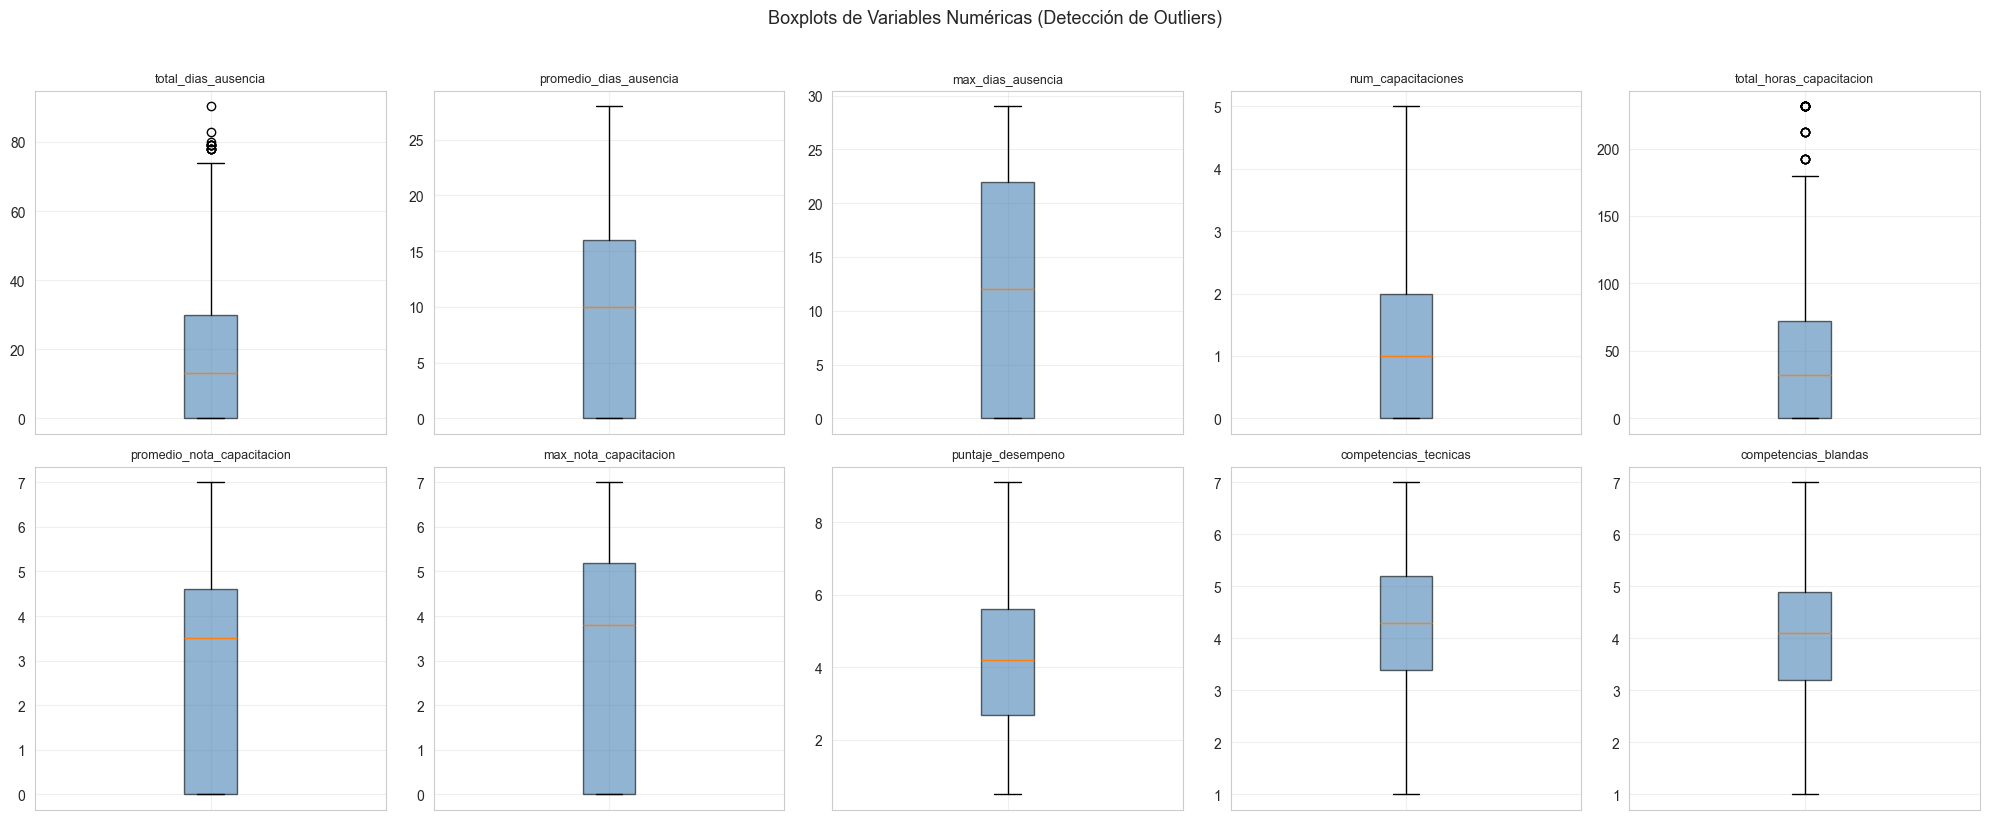

In [9]:
# Boxplots para detectar visualmente los outliers.
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, var in enumerate(vars_numericas):
    axes[i].boxplot(df[var].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(var, fontsize=9)
    axes[i].set_xticklabels([])
    axes[i].grid(alpha=0.3)

plt.suptitle('Boxplots de Variables Numéricas (Detección de Outliers)', fontsize=13, y=1.02)
plt.tight_layout()
os.makedirs(os.path.join(project_root, 'results/plots'), exist_ok=True)
plt.savefig(os.path.join(project_root, 'results/plots/00_outliers_boxplots.png'), dpi=150, bbox_inches='tight')
plt.show()


In [10]:
# Detalle del puntaje de desempeño (variable objetivo).
print("ANÁLISIS DEL PUNTAJE DE DESEMPEÑO (variable objetivo):")
print(f"  Media:    {df['puntaje_desempeno'].mean():.2f}")
print(f"  Mediana:  {df['puntaje_desempeno'].median():.2f}")
print(f"  Std:      {df['puntaje_desempeno'].std():.2f}")
print(f"  Min:      {df['puntaje_desempeno'].min():.2f}")
print(f"  Max:      {df['puntaje_desempeno'].max():.2f}")
print(f"  P99:      {df['puntaje_desempeno'].quantile(0.99):.2f}")

# Registros con puntaje extremadamente alto.
umbral_extremo = df['puntaje_desempeno'].quantile(0.99)
registros_extremos = (df['puntaje_desempeno'] > umbral_extremo).sum()
print(f"\nRegistros con puntaje > P99 ({umbral_extremo:.1f}): {registros_extremos}")

# Registros con puntaje negativo.
registros_negativos = (df['puntaje_desempeno'] < 0).sum()
print(f"Registros con puntaje negativo: {registros_negativos}")


ANÁLISIS DEL PUNTAJE DE DESEMPEÑO (variable objetivo):
  Media:    4.21
  Mediana:  4.20
  Std:      1.96
  Min:      0.50
  Max:      9.10
  P99:      9.10

Registros con puntaje > P99 (9.1): 0
Registros con puntaje negativo: 0


# 6. Limpieza conservadora

Elimino únicamente los registros con valores físicamente imposibles.

No elimino outliers en esta etapa: eso se controla con clipping en la siguiente sección.


In [11]:
registros_antes = len(df)
print(f"Registros antes de limpieza: {registros_antes}")

# Eliminar registros con valores imposibles.
if mask_imposibles.sum() > 0:
    df = df[~mask_imposibles].copy()
    print(f"Registros eliminados (valores imposibles): {registros_antes - len(df)}")
else:
    print("No se encontraron valores imposibles. No se eliminaron registros.")

df = df.reset_index(drop=True)
print(f"Registros después de limpieza: {len(df)}")
print(f"Dimensiones actuales: {df.shape}")


Registros antes de limpieza: 1449
No se encontraron valores imposibles. No se eliminaron registros.
Registros después de limpieza: 1449
Dimensiones actuales: (1449, 37)


# 7. Control de outliers (clipping)

Aplico clipping a las variables con outliers extremos.

El clipping limita los valores al rango [P1, P99] para controlar el efecto de valores extremos sin eliminar registros.

Esto es especialmente importante para el `puntaje_desempeno`, que tiene un valor máximo de 380 siendo la media de 7.37.


In [12]:
# Definir límites de clipping para cada variable.
variables_clipping = {
    'total_dias_ausencia':        (0, df['total_dias_ausencia'].quantile(0.99)),
    'promedio_dias_ausencia':     (0, df['promedio_dias_ausencia'].quantile(0.99)),
    'max_dias_ausencia':          (0, df['max_dias_ausencia'].quantile(0.99)),
    'num_capacitaciones':         (0, df['num_capacitaciones'].quantile(0.99)),
    'total_horas_capacitacion':   (0, df['total_horas_capacitacion'].quantile(0.99)),
    'puntaje_desempeno':          (df['puntaje_desempeno'].quantile(0.01),
                                   df['puntaje_desempeno'].quantile(0.99)),
}

print("LÍMITES DE CLIPPING APLICADOS:")
print("-" * 60)
print(f"{'Variable':<35} {'Límite Inf':>12} {'Límite Sup':>12}")
print("-" * 60)

for var, (lim_inf, lim_sup) in variables_clipping.items():
    antes_min = df[var].min()
    antes_max = df[var].max()
    
    # Guardar valor original antes de clipear.
    df[f'{var}_original'] = df[var].copy()
    
    # Aplicar clipping.
    df[var] = df[var].clip(lower=lim_inf, upper=lim_sup)
    
    registros_afectados = ((df[f'{var}_original'] < lim_inf) | (df[f'{var}_original'] > lim_sup)).sum()
    
    print(f"{var:<35} {lim_inf:>12.2f} {lim_sup:>12.2f}  | afectados: {registros_afectados}")

print("-" * 60)


LÍMITES DE CLIPPING APLICADOS:
------------------------------------------------------------
Variable                              Límite Inf   Límite Sup
------------------------------------------------------------
total_dias_ausencia                         0.00        74.00  | afectados: 13
promedio_dias_ausencia                      0.00        27.00  | afectados: 8
max_dias_ausencia                           0.00        29.00  | afectados: 0
num_capacitaciones                          0.00         5.00  | afectados: 0
total_horas_capacitacion                    0.00       212.00  | afectados: 13
puntaje_desempeno                           0.50         9.10  | afectados: 0
------------------------------------------------------------


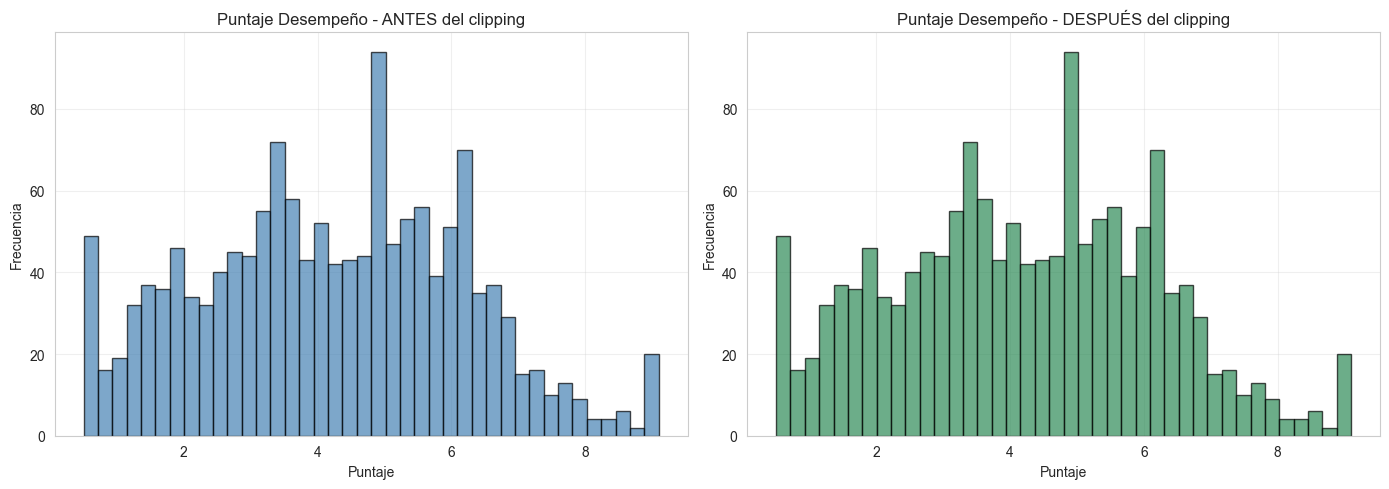

Puntaje desempeño ANTES  -> Min: 0.5 | Max: 9.1
Puntaje desempeño DESPUÉS -> Min: 0.5 | Max: 9.1


In [13]:
# Comparar distribución antes y después del clipping para puntaje_desempeno.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['puntaje_desempeno_original'].dropna(), bins=40,
             color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Puntaje Desempeño - ANTES del clipping')
axes[0].set_xlabel('Puntaje')
axes[0].set_ylabel('Frecuencia')
axes[0].grid(alpha=0.3)

axes[1].hist(df['puntaje_desempeno'].dropna(), bins=40,
             color='seagreen', edgecolor='black', alpha=0.7)
axes[1].set_title('Puntaje Desempeño - DESPUÉS del clipping')
axes[1].set_xlabel('Puntaje')
axes[1].set_ylabel('Frecuencia')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(project_root, 'results/plots/00_clipping_desempeno.png'), dpi=150, bbox_inches='tight')
plt.show()

print("Puntaje desempeño ANTES  -> Min:", df['puntaje_desempeno_original'].min(),
      "| Max:", df['puntaje_desempeno_original'].max())
print("Puntaje desempeño DESPUÉS -> Min:", df['puntaje_desempeno'].min(),
      "| Max:", df['puntaje_desempeno'].max())


# 8. Verificación de variables anómalas

Reviso la columna `ausencias_justificadas`, que en el análisis exploratorio mostró todos los valores en cero.

Una variable constante no aporta información a los modelos y puede generar problemas numéricos.


In [14]:
print("ANÁLISIS DE VARIABLES ANÓMALAS:")
print("-" * 60)

# Revisar columnas disponibles en el dataset
print("\nColumnas disponibles:")
print(df.columns.tolist())

# Verificar si existe ausencias_justificadas
if 'ausencias_justificadas' in df.columns:
    print("\nANÁLISIS DE ausencias_justificadas:")
    print(f"Valores únicos: {df['ausencias_justificadas'].nunique()}")
    print(f"Distribución:")
    print(df['ausencias_justificadas'].value_counts())
    print(f"Porcentaje de ceros: {(df['ausencias_justificadas'] == 0).mean() * 100:.1f}%")
    
    es_constante = df['ausencias_justificadas'].nunique() <= 1
    print(f"\n¿Es variable constante?: {'SÍ - se eliminará' if es_constante else 'NO - se mantiene'}")
else:
    print("\n'ausencias_justificadas' no existe en el dataset.")
    es_constante = False
    print("Continuando con el análisis de otras variables.")

ANÁLISIS DE VARIABLES ANÓMALAS:
------------------------------------------------------------

Columnas disponibles:
['id_evaluacion', 'id_empleado', 'periodo', 'puntaje_desempeno', 'competencias_tecnicas', 'competencias_blandas', 'evaluador', 'periodo_num', 'departamento', 'cargo', 'tipo_contrato', 'jornada', 'total_dias_ausencia', 'num_ausencias', 'promedio_dias_ausencia', 'max_dias_ausencia', 'num_capacitaciones', 'total_horas_capacitacion', 'promedio_nota_capacitacion', 'max_nota_capacitacion', 'ausencia_alta', 'sin_capacitacion', 'capacitacion_intensiva', 'competencia_combinada', 'eficiencia_capacitacion', 'brecha_nota_capacitacion', 'desempeno_bajo', 'riesgo_rotacion', 'riesgo_operacional_rrhh', 'desempeno_alto', 'total_dias_ausencia_log', 'promedio_dias_ausencia_log', 'max_dias_ausencia_log', 'num_capacitaciones_log', 'total_horas_capacitacion_log', 'riesgo_operacional_rrhh_log', 'competencia_combinada_log', 'total_dias_ausencia_original', 'promedio_dias_ausencia_original', 'max_

In [15]:
# Eliminar columna constante si aplica.
columnas_eliminar = []

if es_constante:
    columnas_eliminar.append('ausencias_justificadas')
    print("Columna 'ausencias_justificadas' añadida para eliminación (constante).")

# También eliminar columnas auxiliares '_original' antes de continuar.
# Las conservamos hasta el final del notebook para documentación.
print(f"\nColumnas a eliminar: {columnas_eliminar}")



Columnas a eliminar: []


# 9. Recálculo de variables derivadas

Verifico la consistencia de las variables derivadas y recalculo las que lo requieran.

Compruebo que los ratios calculados sean coherentes con los datos fuente.


In [16]:
print("VERIFICACIÓN DE CONSISTENCIA DE VARIABLES DERIVADAS:")
print("-" * 60)

# Verificar que max_dias_ausencia >= promedio_dias_ausencia.
inconsistencia_max_prom = (df['max_dias_ausencia'] < df['promedio_dias_ausencia']).sum()
print(f"Registros donde max_ausencia < promedio_ausencia: {inconsistencia_max_prom}")

# Verificar que total_dias_ausencia >= max_dias_ausencia.
inconsistencia_total_max = (df['total_dias_ausencia'] < df['max_dias_ausencia']).sum()
print(f"Registros donde total_ausencia < max_ausencia: {inconsistencia_total_max}")

# Verificar que max_nota_capacitacion >= promedio_nota_capacitacion.
inconsistencia_nota = (df['max_nota_capacitacion'] < df['promedio_nota_capacitacion']).sum()
print(f"Registros donde max_nota < promedio_nota: {inconsistencia_nota}")

# Verificar empleados con 0 capacitaciones pero con horas > 0.
inconsistencia_cap_horas = ((df['num_capacitaciones'] == 0) & (df['total_horas_capacitacion'] > 0)).sum()
print(f"Registros con 0 capacitaciones pero horas > 0: {inconsistencia_cap_horas}")

print("\nVerificación completada.")


VERIFICACIÓN DE CONSISTENCIA DE VARIABLES DERIVADAS:
------------------------------------------------------------
Registros donde max_ausencia < promedio_ausencia: 0
Registros donde total_ausencia < max_ausencia: 0
Registros donde max_nota < promedio_nota: 0
Registros con 0 capacitaciones pero horas > 0: 7

Verificación completada.


# 10. Nuevas variables de riesgo operacional RRHH

Creo nuevas variables que capturan información relevante para predecir el desempeño de empleados.

Estas variables tienen interpretación directa en el contexto de recursos humanos:
- **ausencia_alta:** empleados con ausencias en el cuartil superior.
- **sin_capacitacion:** empleados que no tuvieron capacitaciones.
- **capacitacion_intensiva:** empleados con muchas horas de capacitación.
- **riesgo_rotacion:** combinación de alta ausencia y bajo desempeño.
- **competencia_combinada:** promedio de competencias técnicas y blandas.
- **ratio_nota_capacitacion:** rendimiento por hora de capacitación.


In [17]:
# Umbrales para variables binarias.
p75_ausencia  = df['total_dias_ausencia'].quantile(0.75)
p25_desempeno = df['puntaje_desempeno'].quantile(0.25)
p75_horas     = df['total_horas_capacitacion'].quantile(0.75)

print("UMBRALES UTILIZADOS:")
print(f"  P75 ausencias:         {p75_ausencia:.1f} días")
print(f"  P25 desempeño:         {p25_desempeno:.2f} puntos")
print(f"  P75 horas capacitación:{p75_horas:.1f} horas")

# --- Variables binarias de riesgo ---

# 1. Ausencia alta.
df['ausencia_alta'] = (df['total_dias_ausencia'] > p75_ausencia).astype(int)

# 2. Sin capacitación.
df['sin_capacitacion'] = (df['num_capacitaciones'] == 0).astype(int)

# 3. Capacitación intensiva.
df['capacitacion_intensiva'] = (df['total_horas_capacitacion'] > p75_horas).astype(int)

# 4. Desempeño bajo.
df['desempeno_bajo'] = (df['puntaje_desempeno'] < p25_desempeno).astype(int)

# 5. Riesgo de rotación: alta ausencia + bajo desempeño.
df['riesgo_rotacion'] = ((df['ausencia_alta'] == 1) & (df['desempeno_bajo'] == 1)).astype(int)

# --- Variables continuas derivadas ---

# 6. Competencia combinada: promedio de técnicas y blandas.
df['competencia_combinada'] = (df['competencias_tecnicas'] + df['competencias_blandas']) / 2

# 7. Ratio nota por hora de capacitación (eficiencia de capacitación).
df['eficiencia_capacitacion'] = np.where(
    df['total_horas_capacitacion'] > 0,
    df['promedio_nota_capacitacion'] / df['total_horas_capacitacion'],
    0
)

# 8. Brecha entre máxima nota y promedio (consistencia en capacitaciones).
df['brecha_nota_capacitacion'] = df['max_nota_capacitacion'] - df['promedio_nota_capacitacion']

print("\nNUEVAS VARIABLES CREADAS:")
nuevas_vars = ['ausencia_alta', 'sin_capacitacion', 'capacitacion_intensiva',
               'desempeno_bajo', 'riesgo_rotacion', 'competencia_combinada',
               'eficiencia_capacitacion', 'brecha_nota_capacitacion']
print(df[nuevas_vars].describe().round(3))


UMBRALES UTILIZADOS:
  P75 ausencias:         30.0 días
  P25 desempeño:         2.70 puntos
  P75 horas capacitación:72.0 horas

NUEVAS VARIABLES CREADAS:
       ausencia_alta  sin_capacitacion  capacitacion_intensiva  \
count       1449.000          1449.000                1449.000   
mean           0.240             0.256                   0.246   
std            0.427             0.437                   0.431   
min            0.000             0.000                   0.000   
25%            0.000             0.000                   0.000   
50%            0.000             0.000                   0.000   
75%            0.000             1.000                   0.000   
max            1.000             1.000                   1.000   

       desempeno_bajo  riesgo_rotacion  competencia_combinada  \
count        1449.000         1449.000               1449.000   
mean            0.235            0.054                  4.152   
std             0.424            0.226                

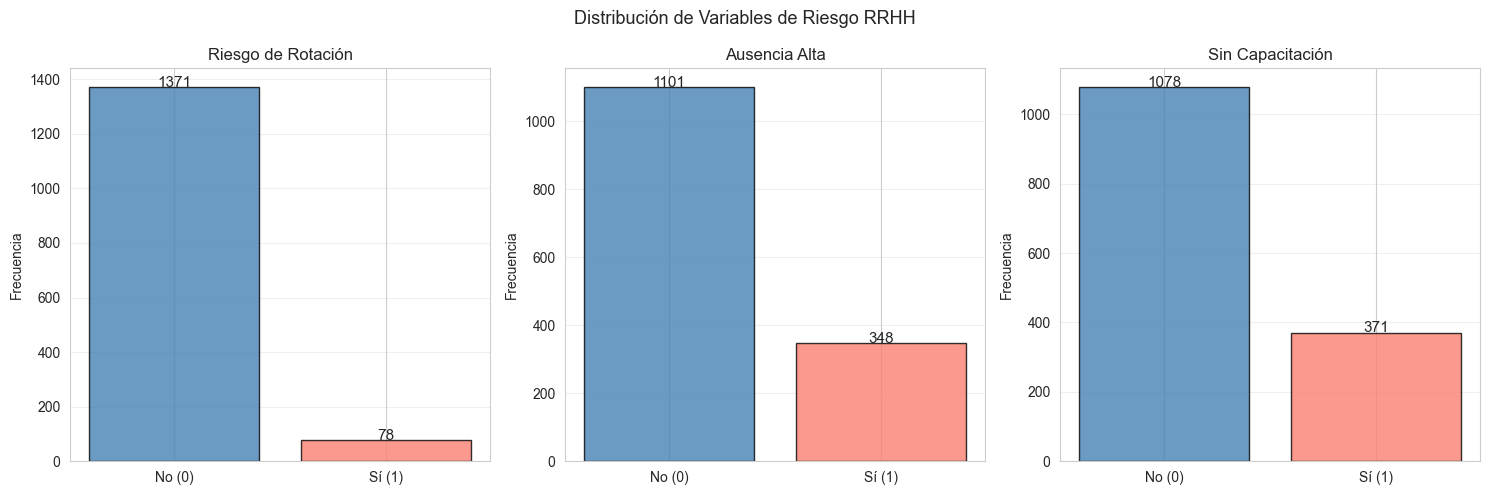

In [18]:
# Distribución de variables binarias de riesgo.
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

vars_binarias = ['riesgo_rotacion', 'ausencia_alta', 'sin_capacitacion']
titulos = ['Riesgo de Rotación', 'Ausencia Alta', 'Sin Capacitación']

for ax, var, titulo in zip(axes, vars_binarias, titulos):
    conteo = df[var].value_counts().sort_index()
    ax.bar(['No (0)', 'Sí (1)'], conteo.values,
           color=['steelblue', 'salmon'], edgecolor='black', alpha=0.8)
    ax.set_title(titulo)
    ax.set_ylabel('Frecuencia')
    ax.grid(alpha=0.3, axis='y')
    for i, v in enumerate(conteo.values):
        ax.text(i, v + 1, str(v), ha='center', fontsize=11)

plt.suptitle('Distribución de Variables de Riesgo RRHH', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(project_root, 'results/plots/00_variables_riesgo.png'), dpi=150, bbox_inches='tight')
plt.show()


# 11. Transformaciones logarítmicas

Aplico `log1p` (logaritmo de 1 + x) a variables con distribución sesgada a la derecha.

Esta transformación reduce el impacto de valores extremos y acerca la distribución a una forma normal,
lo que mejora el rendimiento de muchos modelos de Machine Learning.

Se usa `log1p` en lugar de `log` para manejar correctamente valores igual a cero.


In [19]:
# Variables a transformar con log1p.
vars_log = [
    'total_dias_ausencia',
    'promedio_dias_ausencia',
    'max_dias_ausencia',
    'num_capacitaciones',
    'total_horas_capacitacion',
    'competencia_combinada',
    'riesgo_operacional_rrhh'
]

# riesgo_operacional_rrhh: suma de flags de riesgo SIN incluir variable derivada del target.
# CORRECTO: ausencia_alta + sin_capacitacion (ambas son observables antes de conocer el desempeño)
# INCORRECTO (data leakage): usar desempeno_bajo que se calcula desde puntaje_desempeno
df['riesgo_operacional_rrhh'] = df['ausencia_alta'] + df['sin_capacitacion']

print("TRANSFORMACIONES LOGARÍTMICAS:")
print("-" * 60)

for var in vars_log:
    if var in df.columns:
        min_val = df[var].min()
        if min_val < 0:
            print(f"  ADVERTENCIA: {var} tiene min={min_val:.2f}, ajustando a 0 antes de log1p")
            df[var] = df[var].clip(lower=0)

        df[f'{var}_log'] = np.log1p(df[var])
        print(f"  {var}_log creado | original: [{df[var].min():.2f}, {df[var].max():.2f}] "
              f"-> log: [{df[f'{var}_log'].min():.3f}, {df[f'{var}_log'].max():.3f}]")

print("\nTransformaciones logarítmicas completadas.")


TRANSFORMACIONES LOGARÍTMICAS:
------------------------------------------------------------
  total_dias_ausencia_log creado | original: [0.00, 74.00] -> log: [0.000, 4.317]
  promedio_dias_ausencia_log creado | original: [0.00, 27.00] -> log: [0.000, 3.332]
  max_dias_ausencia_log creado | original: [0.00, 29.00] -> log: [0.000, 3.401]
  num_capacitaciones_log creado | original: [0.00, 5.00] -> log: [0.000, 1.792]
  total_horas_capacitacion_log creado | original: [0.00, 212.00] -> log: [0.000, 5.361]
  competencia_combinada_log creado | original: [1.15, 7.00] -> log: [0.765, 2.079]
  riesgo_operacional_rrhh_log creado | original: [0.00, 2.00] -> log: [0.000, 1.099]

Transformaciones logarítmicas completadas.


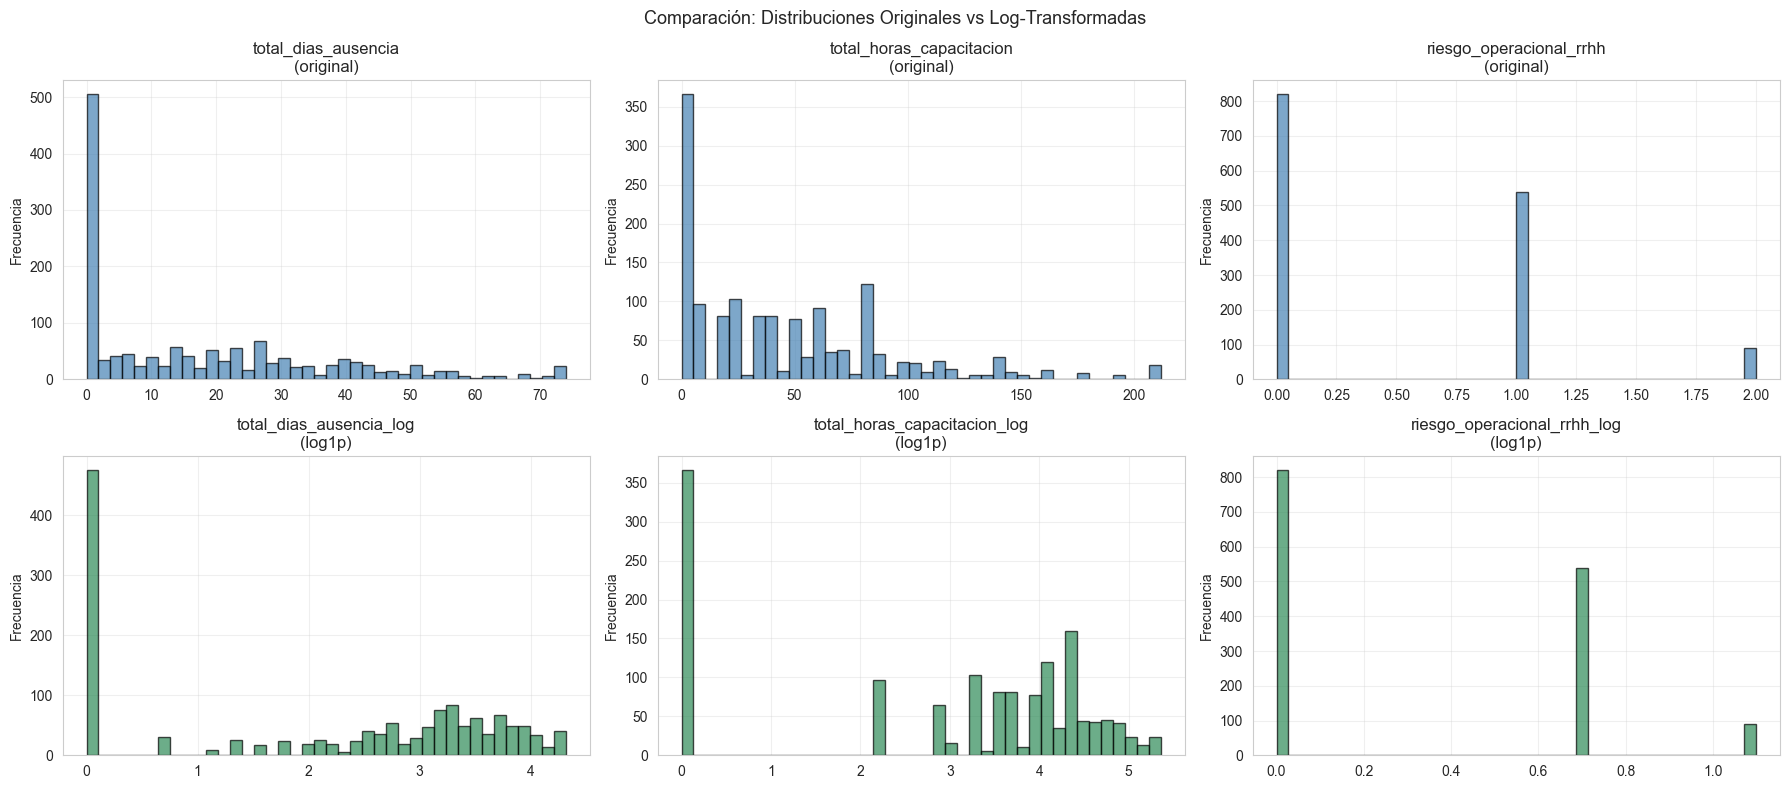

In [20]:
# Comparar distribuciones antes y después de la transformación log.
vars_comparar = ['total_dias_ausencia', 'total_horas_capacitacion', 'riesgo_operacional_rrhh']

fig, axes = plt.subplots(2, 3, figsize=(18, 8))

for j, var in enumerate(vars_comparar):
    if var in df.columns:
        # Original.
        axes[0, j].hist(df[var].dropna(), bins=40, color='steelblue', edgecolor='black', alpha=0.7)
        axes[0, j].set_title(f'{var}\n(original)')
        axes[0, j].set_ylabel('Frecuencia')
        axes[0, j].grid(alpha=0.3)

        # Log transformada.
        var_log = f'{var}_log'
        if var_log in df.columns:
            axes[1, j].hist(df[var_log].dropna(), bins=40, color='seagreen', edgecolor='black', alpha=0.7)
            axes[1, j].set_title(f'{var_log}\n(log1p)')
            axes[1, j].set_ylabel('Frecuencia')
            axes[1, j].grid(alpha=0.3)

plt.suptitle('Comparación: Distribuciones Originales vs Log-Transformadas', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(project_root, 'results/plots/00_transformaciones_log.png'), dpi=150, bbox_inches='tight')
plt.show()


# 12. Construcción del dataset final limpio

Construyo el dataset final eliminando columnas auxiliares (`_original`) y variables constantes.

El dataset final conserva las variables originales limpias, las variables nuevas de riesgo y las transformaciones logarítmicas.


In [21]:
# Eliminar columnas auxiliares '_original'.
cols_original = [c for c in df.columns if c.endswith('_original')]
df_limpio = df.drop(columns=cols_original + columnas_eliminar, errors='ignore').copy()

print("DATASET FINAL LIMPIO:")
print(f"  Dimensiones: {df_limpio.shape}")
print(f"  Columnas eliminadas (auxiliares): {cols_original}")
print(f"  Columnas eliminadas (constantes): {columnas_eliminar}")
print(f"\nColumnas del dataset final:")
for i, col in enumerate(df_limpio.columns, 1):
    print(f"  {i:2d}. {col}")


DATASET FINAL LIMPIO:
  Dimensiones: (1449, 37)
  Columnas eliminadas (auxiliares): ['total_dias_ausencia_original', 'promedio_dias_ausencia_original', 'max_dias_ausencia_original', 'num_capacitaciones_original', 'total_horas_capacitacion_original', 'puntaje_desempeno_original']
  Columnas eliminadas (constantes): []

Columnas del dataset final:
   1. id_evaluacion
   2. id_empleado
   3. periodo
   4. puntaje_desempeno
   5. competencias_tecnicas
   6. competencias_blandas
   7. evaluador
   8. periodo_num
   9. departamento
  10. cargo
  11. tipo_contrato
  12. jornada
  13. total_dias_ausencia
  14. num_ausencias
  15. promedio_dias_ausencia
  16. max_dias_ausencia
  17. num_capacitaciones
  18. total_horas_capacitacion
  19. promedio_nota_capacitacion
  20. max_nota_capacitacion
  21. ausencia_alta
  22. sin_capacitacion
  23. capacitacion_intensiva
  24. competencia_combinada
  25. eficiencia_capacitacion
  26. brecha_nota_capacitacion
  27. desempeno_bajo
  28. riesgo_rotacion
  

In [22]:
# Verificación final de nulos.
nulos_finales = df_limpio.isnull().sum().sum()
print(f"Total valores nulos en dataset final: {nulos_finales}")

# Estadísticas descriptivas finales.
df_limpio.describe().round(3)


Total valores nulos en dataset final: 242


,id_evaluacion,id_empleado,puntaje_desempeno,competencias_tecnicas,competencias_blandas,periodo_num,total_dias_ausencia,num_ausencias,promedio_dias_ausencia,max_dias_ausencia,num_capacitaciones,total_horas_capacitacion,promedio_nota_capacitacion,max_nota_capacitacion,ausencia_alta,sin_capacitacion,capacitacion_intensiva,competencia_combinada,eficiencia_capacitacion,brecha_nota_capacitacion,desempeno_bajo,riesgo_rotacion,riesgo_operacional_rrhh,desempeno_alto,total_dias_ausencia_log,promedio_dias_ausencia_log,max_dias_ausencia_log,num_capacitaciones_log,total_horas_capacitacion_log,riesgo_operacional_rrhh_log,competencia_combinada_log
count,1432.000,1449.000,1449.000,1449.000,1449.000,1449.000,1449.000,1449.000,1449.000,1449.000,1449.000,1449.000,1449.000,1449.000,1449.000,1449.000,1449.000,1449.000,1449.000,1449.000,1449.000,1449.000,1449.000,1449.00,1449.000,1449.000,1449.000,1449.000,1449.000,1449.000,1449.000
mean,761.809,323.030,4.210,4.235,4.069,2.929,17.974,1.246,9.536,11.857,1.269,45.703,3.003,3.284,0.240,0.256,0.246,4.152,0.096,0.281,0.235,0.054,0.496,0.51,2.049,1.732,1.863,0.700,2.882,0.326,1.617
std,429.874,141.384,1.957,1.337,1.337,1.479,19.305,1.215,8.707,10.581,1.127,46.204,2.113,2.309,0.427,0.437,0.431,1.042,0.137,0.539,0.424,0.226,0.612,0.50,1.588,1.308,1.406,0.492,1.812,0.384,0.214
min,1.000,2.000,0.500,1.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.150,0.000,0.000,0.000,0.000,0.000,0.00,0.000,0.000,0.000,0.000,0.000,0.000,0.765
25%,389.750,227.000,2.700,3.400,3.200,2.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,3.450,0.000,0.000,0.000,0.000,0.000,0.00,0.000,0.000,0.000,0.000,0.000,0.000,1.493
50%,774.500,360.000,4.200,4.300,4.100,3.000,13.000,1.000,10.000,12.000,1.000,32.000,3.500,3.800,0.000,0.000,0.000,4.200,0.053,0.000,0.000,0.000,0.000,1.00,2.639,2.398,2.565,0.693,3.497,0.000,1.649
75%,1132.250,435.000,5.600,5.200,4.900,4.000,30.000,2.000,16.000,22.000,2.000,72.000,4.600,5.200,0.000,1.000,0.000,4.850,0.115,0.350,0.000,0.000,1.000,1.00,3.434,2.833,3.135,1.099,4.290,0.693,1.766
max,1490.000,509.000,9.100,7.000,7.000,5.000,74.000,5.000,27.000,29.000,5.000,212.000,7.000,7.000,1.000,1.000,1.000,7.000,0.875,3.500,1.000,1.000,2.000,1.00,4.317,3.332,3.401,1.792,5.361,1.099,2.079


In [23]:
# Vista de las primeras filas del dataset final.
df_limpio.head()


,id_evaluacion,id_empleado,periodo,puntaje_desempeno,competencias_tecnicas,competencias_blandas,evaluador,periodo_num,departamento,cargo,tipo_contrato,jornada,total_dias_ausencia,num_ausencias,promedio_dias_ausencia,max_dias_ausencia,num_capacitaciones,total_horas_capacitacion,promedio_nota_capacitacion,max_nota_capacitacion,ausencia_alta,sin_capacitacion,capacitacion_intensiva,competencia_combinada,eficiencia_capacitacion,brecha_nota_capacitacion,desempeno_bajo,riesgo_rotacion,riesgo_operacional_rrhh,desempeno_alto,total_dias_ausencia_log,promedio_dias_ausencia_log,max_dias_ausencia_log,num_capacitaciones_log,total_horas_capacitacion_log,riesgo_operacional_rrhh_log,competencia_combinada_log
0,1.0,252,2023-S2,3.6,2.2,4.5,Pedro González Rojas,4,Finanzas,Analista,Honorarios,NaN,30.0,3.0,10.0,21.0,1.0,16.0,2.30,2.3,0,0,0,3.35,0.143750,0.00,0,0,0,0,3.433987,2.397895,3.091042,0.693147,2.833213,0.000000,1.470176
1,2.0,135,2023-S1,2.6,3.7,4.0,Marcela Araya Aguilera,3,Finanzas,Jefe,Plazo Fijo,Completa,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0,1,0,3.85,0.000000,0.00,1,0,1,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.693147,1.578979
2,3.0,11,2022-S2,5.6,1.9,6.8,Ignacio Castro Pérez,2,Rrhh,Jefe,Plazo Fijo,Completa,11.0,1.0,11.0,11.0,2.0,48.0,2.65,4.1,0,0,0,4.35,0.055208,1.45,0,0,0,1,2.484907,2.484907,2.484907,1.098612,3.891820,0.000000,1.677097
3,5.0,148,2022-S2,1.4,5.0,6.4,Agustín Muñoz Valenzuela,2,Logística,Director,Plazo Fijo,NaN,21.0,1.0,21.0,21.0,2.0,100.0,2.05,2.8,0,0,1,5.70,0.020500,0.75,1,0,0,0,3.091042,3.091042,3.091042,1.098612,4.615121,0.000000,1.902108
4,6.0,80,2023-S1,3.2,1.4,5.1,Ignacio Díaz Reyes,3,Ventas,Coordinador,Indefinido,Por Turnos,2.0,1.0,2.0,2.0,1.0,80.0,1.40,1.4,0,0,1,3.25,0.017500,0.00,0,0,0,0,1.098612,1.098612,1.098612,0.693147,4.394449,0.000000,1.446919


# 13. Guardado del dataset limpio

Guardo el dataset transformado en la carpeta `data/05_model_input`.

Este archivo será la base para los notebooks posteriores de análisis, modelado y evaluación.


In [24]:
# Crear carpeta de salida si no existe.
ruta_salida_dir = os.path.join(project_root, 'data/05_model_input')
os.makedirs(ruta_salida_dir, exist_ok=True)

ruta_salida = os.path.join(ruta_salida_dir, 'dataset_rrhh_limpio.csv')

df_limpio.to_csv(ruta_salida, index=False, encoding='utf-8')

print("Dataset limpio guardado correctamente en:")
print(ruta_salida)
print(f"\nRegistros: {len(df_limpio)} | Columnas: {df_limpio.shape[1]}")


Dataset limpio guardado correctamente en:
C:\Users\Arturo\prueba2\data/05_model_input\dataset_rrhh_limpio.csv

Registros: 1449 | Columnas: 37


In [25]:
import pandas as pd
import numpy as np
import os

project_root = r'C:\Users\Arturo\prueba2'
ruta_raw    = os.path.join(project_root, 'data', '01_raw')
ruta_output = os.path.join(project_root, 'data', '05_model_input')

# ── 1. Cargar fuentes crudas ───────────────────────────────────────────────
empleados      = pd.read_csv(os.path.join(ruta_raw, 'empleados.csv'))
ausencias      = pd.read_csv(os.path.join(ruta_raw, 'ausencias.csv'))
capacitaciones = pd.read_csv(os.path.join(ruta_raw, 'capacitaciones.csv'))
evaluaciones   = pd.read_csv(os.path.join(ruta_raw, 'evaluaciones.csv'))

# ── 2. Normalizar categorías y limpiar IDs ────────────────────────────────
for col in ['departamento', 'cargo', 'tipo_contrato', 'jornada']:
    empleados[col] = empleados[col].str.strip().str.title()

for df_t, col in [(empleados, 'id_empleado'), (ausencias, 'id_empleado'),
                  (capacitaciones, 'id_empleado'), (evaluaciones, 'id_empleado')]:
    df_t[col] = pd.to_numeric(df_t[col], errors='coerce')

# ── 3. Parsear fechas (formatos mixtos: ISO y DD/MM/YYYY) ─────────────────
ausencias['fecha_inicio']      = pd.to_datetime(ausencias['fecha_inicio'],      errors='coerce', dayfirst=True)
capacitaciones['fecha_inicio'] = pd.to_datetime(capacitaciones['fecha_inicio'], errors='coerce', dayfirst=True)
ausencias['dias']              = pd.to_numeric(ausencias['dias'], errors='coerce')

# ── 4. Preparar evaluaciones ───────────────────────────────────────────────
PERIODO_NUM = {'2022-S1': 1, '2022-S2': 2, '2023-S1': 3, '2023-S2': 4, '2024-S1': 5}
# Fecha de corte: último día del semestre de evaluación
PERIODO_CORTE = {
    '2022-S1': pd.Timestamp('2022-06-30'),
    '2022-S2': pd.Timestamp('2022-12-31'),
    '2023-S1': pd.Timestamp('2023-06-30'),
    '2023-S2': pd.Timestamp('2023-12-31'),
    '2024-S1': pd.Timestamp('2024-06-30'),
}

ev = evaluaciones.dropna(subset=['id_empleado', 'puntaje_desempeno']).copy()
p1, p99 = ev['puntaje_desempeno'].quantile([0.01, 0.99])
ev['puntaje_desempeno']     = ev['puntaje_desempeno'].clip(p1, p99)
ev['competencias_tecnicas'] = ev['competencias_tecnicas'].fillna(ev['competencias_tecnicas'].median())
ev['competencias_blandas']  = ev['competencias_blandas'].fillna(ev['competencias_blandas'].median())
ev['periodo_num']  = ev['periodo'].map(PERIODO_NUM).fillna(0).astype(int)
ev['fecha_corte']  = ev['periodo'].map(PERIODO_CORTE).fillna(pd.Timestamp('2024-12-31'))

# ── 5. Unir con empleados ──────────────────────────────────────────────────
df2 = ev.merge(
    empleados[['id_empleado', 'departamento', 'cargo', 'tipo_contrato', 'jornada']],
    on='id_empleado', how='left'
)

# ── 6. Agregación TEMPORAL de ausencias ───────────────────────────────────
# Solo se incluyen ausencias con fecha_inicio conocida y anterior al corte del periodo.
# Esto evita que una evaluación del 2022-S1 use ausencias que ocurrieron en 2023.
aus_v = ausencias.dropna(subset=['id_empleado', 'dias', 'fecha_inicio']).copy()
aus_v = aus_v[aus_v['dias'] >= 0]

ev_p = df2[['id_empleado', 'periodo', 'fecha_corte']].copy()
aus_ev = ev_p.merge(aus_v[['id_empleado', 'fecha_inicio', 'dias']], on='id_empleado', how='left')
aus_ev = aus_ev[aus_ev['fecha_inicio'] <= aus_ev['fecha_corte']]

aus_agg = aus_ev.groupby(['id_empleado', 'periodo']).agg(
    total_dias_ausencia    = ('dias', 'sum'),
    num_ausencias          = ('dias', 'count'),
    promedio_dias_ausencia = ('dias', 'mean'),
    max_dias_ausencia      = ('dias', 'max'),
).reset_index()

df2 = df2.merge(aus_agg, on=['id_empleado', 'periodo'], how='left')
for c in ['total_dias_ausencia', 'num_ausencias', 'promedio_dias_ausencia', 'max_dias_ausencia']:
    df2[c] = df2[c].fillna(0)

# Clipping de ausencias (P99) para controlar extremos
for c in ['total_dias_ausencia', 'promedio_dias_ausencia', 'max_dias_ausencia']:
    df2[c] = df2[c].clip(upper=df2[c].quantile(0.99))

# ── 7. Agregación TEMPORAL de capacitaciones ──────────────────────────────
cap_v = capacitaciones.dropna(subset=['id_empleado', 'fecha_inicio']).copy()
cap_v['horas']      = pd.to_numeric(cap_v['horas'],      errors='coerce').fillna(0)
cap_v['nota_final'] = pd.to_numeric(cap_v['nota_final'], errors='coerce')

cap_ev = ev_p.merge(cap_v[['id_empleado', 'fecha_inicio', 'horas', 'nota_final']], on='id_empleado', how='left')
cap_ev = cap_ev[cap_ev['fecha_inicio'] <= cap_ev['fecha_corte']]

cap_agg = cap_ev.groupby(['id_empleado', 'periodo']).agg(
    num_capacitaciones         = ('horas',      'count'),
    total_horas_capacitacion   = ('horas',      'sum'),
    promedio_nota_capacitacion = ('nota_final', 'mean'),
    max_nota_capacitacion      = ('nota_final', 'max'),
).reset_index()

df2 = df2.merge(cap_agg, on=['id_empleado', 'periodo'], how='left')
for c in ['num_capacitaciones', 'total_horas_capacitacion', 'promedio_nota_capacitacion', 'max_nota_capacitacion']:
    df2[c] = df2[c].fillna(0)

df2['total_horas_capacitacion'] = df2['total_horas_capacitacion'].clip(
    upper=df2['total_horas_capacitacion'].quantile(0.99)
)

# ── 8. Feature engineering SIN data leakage ───────────────────────────────
p75_aus   = df2['total_dias_ausencia'].quantile(0.75)
p75_horas = df2['total_horas_capacitacion'].quantile(0.75)

df2['ausencia_alta']           = (df2['total_dias_ausencia']      >= p75_aus).astype(int)
df2['sin_capacitacion']        = (df2['num_capacitaciones']       == 0).astype(int)
df2['capacitacion_intensiva']  = (df2['total_horas_capacitacion'] >= p75_horas).astype(int)
df2['competencia_combinada']   = df2['competencias_tecnicas'] + df2['competencias_blandas']
df2['eficiencia_capacitacion'] = np.where(
    df2['total_horas_capacitacion'] > 0,
    df2['promedio_nota_capacitacion'] / df2['total_horas_capacitacion'], 0
)
df2['brecha_nota_capacitacion'] = df2['max_nota_capacitacion'] - df2['promedio_nota_capacitacion']

# riesgo_operacional_rrhh: SOLO flags observables, sin target derivado
# ausencia_alta=1 + sin_capacitacion=1 → riesgo 0, 1 o 2
df2['riesgo_operacional_rrhh'] = df2['ausencia_alta'] + df2['sin_capacitacion']

# ── 9. Variables derivadas del TARGET (NO usar como features en modelos) ───
p25_des = df2['puntaje_desempeno'].quantile(0.25)
p75_des = df2['puntaje_desempeno'].quantile(0.75)
df2['desempeno_bajo']  = (df2['puntaje_desempeno'] <= p25_des).astype(int)
df2['riesgo_rotacion'] = ((df2['ausencia_alta'] == 1) & (df2['desempeno_bajo'] == 1)).astype(int)
df2['desempeno_alto']  = (df2['puntaje_desempeno'] >= p75_des).astype(int)  # TARGET OFICIAL (P75)

# ── 10. Transformaciones logarítmicas ──────────────────────────────────────
for col in ['total_dias_ausencia', 'promedio_dias_ausencia', 'max_dias_ausencia',
            'num_capacitaciones', 'total_horas_capacitacion',
            'riesgo_operacional_rrhh', 'competencia_combinada']:
    df2[f'{col}_log'] = np.log1p(df2[col])

# ── 11. Guardar dataset final ──────────────────────────────────────────────
df2 = df2.drop(columns=['fecha_corte'])
os.makedirs(ruta_output, exist_ok=True)
ruta_guardar = os.path.join(ruta_output, 'dataset_rrhh_limpio.csv')
df2.to_csv(ruta_guardar, index=False)

print(f"Dataset guardado: {ruta_guardar}")
print(f"Registros: {len(df2)} | Columnas: {df2.shape[1]}")
print(f"\nColumnas ({df2.shape[1]}):")
print(df2.columns.tolist())
print(f"\nDistribución desempeno_alto (P75):")
print(df2['desempeno_alto'].value_counts())
print(f"\nNulos por columna (solo con nulos):")
nulos = df2.isnull().sum()
print(nulos[nulos > 0])


Dataset guardado: C:\Users\Arturo\prueba2\data\05_model_input\dataset_rrhh_limpio.csv
Registros: 1449 | Columnas: 37

Columnas (37):
['id_evaluacion', 'id_empleado', 'periodo', 'puntaje_desempeno', 'competencias_tecnicas', 'competencias_blandas', 'evaluador', 'periodo_num', 'departamento', 'cargo', 'tipo_contrato', 'jornada', 'total_dias_ausencia', 'num_ausencias', 'promedio_dias_ausencia', 'max_dias_ausencia', 'num_capacitaciones', 'total_horas_capacitacion', 'promedio_nota_capacitacion', 'max_nota_capacitacion', 'ausencia_alta', 'sin_capacitacion', 'capacitacion_intensiva', 'competencia_combinada', 'eficiencia_capacitacion', 'brecha_nota_capacitacion', 'riesgo_operacional_rrhh', 'desempeno_bajo', 'riesgo_rotacion', 'desempeno_alto', 'total_dias_ausencia_log', 'promedio_dias_ausencia_log', 'max_dias_ausencia_log', 'num_capacitaciones_log', 'total_horas_capacitacion_log', 'riesgo_operacional_rrhh_log', 'competencia_combinada_log']

Distribución desempeno_alto (P75):
desempeno_alto
0   

# 14. Conclusiones del notebook

En este notebook se preparó una versión mejorada del dataset de RRHH.

Las principales decisiones fueron:

- eliminar solo valores físicamente imposibles (ninguno encontrado en este caso);
- evitar una limpieza demasiado agresiva para no perder información operacional;
- controlar el outlier extremo de `puntaje_desempeno` (máx. 380) mediante clipping al P99;
- documentar y eliminar la columna `ausencias_justificadas` por ser constante (todos ceros);
- verificar la consistencia de variables derivadas (max, promedio, total de ausencias);
- crear variables de riesgo RRHH con interpretación directa (`riesgo_rotacion`, `ausencia_alta`, etc.);
- aplicar transformaciones logarítmicas para variables con distribución muy sesgada;
- conservar la mayor cantidad posible de registros (309 empleados mantenidos).

El resultado final es `dataset_rrhh_limpio.csv`, una base más estable y preparada para las etapas de análisis, modelado supervisado, optimización y aprendizaje no supervisado.


# 15. Pipeline de producción: versión corregida del dataset

Esta celda reemplaza la sección 13 como fuente del archivo `dataset_rrhh_limpio.csv`.

**Mejoras respecto al pipeline anterior:**

1. **Agregación temporal de ausencias y capacitaciones:** solo se usan registros anteriores a la fecha de corte del periodo de evaluación. Esto elimina el leakage temporal (evita que una evaluación del 2022-S1 use ausencias del 2023).

2. **`riesgo_operacional_rrhh` sin data leakage:** se define como `ausencia_alta + sin_capacitacion`. La versión anterior incluía `desempeno_bajo`, que es una variable derivada del target y no debe usarse como feature.

3. **Variables target-derived claramente documentadas:** `desempeno_bajo`, `riesgo_rotacion` y `desempeno_alto` se mantienen en el dataset pero están marcadas para no usarse como features en los modelos.